# Ноутбук 02: Классификация текста — анализ GoEmotions

**Задача:** определить тональность комментариев на reddit.

**Датасет:** [GoEmotions](https://huggingface.co/datasets/go_emotions)
- Датасет комментариев с Reddit
- Multi-label разметка: один текст может иметь несколько эмоций одновременно
- Используется 28 меток: 27 эмоций + `neutral`

**Модели:**
- `sangkm/go-emotions-fine-tuned-distilroberta` — более лёгкая модель на базе DistilRoBERTa
- `IsaacZhy/roberta-large-goemotions` — более тяжёлая модель на базе RoBERTa-large

**Что будем делать:**
1. Загрузить датасет GoEmotions
2. Изучить данные
3. Запустить inference на тестовой выборке
4. Посчитать метрики качества
5. Сравнить предсказания лёгкой и тяжёлой моделей
6. Посмотреть на ошибки и расхождения моделей
7. Протестировать модели на собственных примерах

In [46]:
# Импорты
from datasets import load_dataset
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
import torch
import numpy as np
from collections import Counter

print('Версия torch:', torch.__version__)
print('GPU доступен:', torch.cuda.is_available())

Версия torch: 2.11.0+cu130
GPU доступен: False


## Шаг 1: Загрузка датасета IMDB

In [47]:
# Загружаем датасет GoEmotions через HuggingFace datasets
dataset = load_dataset('go_emotions', 'simplified')

print('Структура датасета:')
print(dataset)
print()
print(f'Обучающих примеров: {len(dataset["train"])}')
print(f'Тестовых примеров:  {len(dataset["test"])}')

Структура датасета:
DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})

Обучающих примеров: 43410
Тестовых примеров:  5427


In [48]:
print(f'Тестовых примеров:    {len(dataset["test"]):,}')
# Список эмоций / меток
label_names = dataset['train'].features['labels'].feature.names
id2label = {i: name for i, name in enumerate(label_names)}
num_labels = len(label_names)

print(f'Количество меток: {num_labels}')
print('Метки:')
print(label_names)

# Смотрим на первые примеры
print('=== Позитивная рецензия (label=1) ===')
pos_example = next(x for x in dataset['train'] if x['labels'][0] == label_names.index('joy'))
print(f'Метка: {label_names[pos_example["labels"][0]]} (1 = позитивная)')
print(f'Текст: {pos_example["text"][:300]}...')
print()

# Найдём негативную
neg_example = next(x for x in dataset['train'] if x['labels'][0] == label_names.index('anger'))
print('=== Негативная рецензия (label=0) ===')
print(f'Метка: {label_names[neg_example["labels"][0]]} (0 = негативная)')
print(f'Текст: {neg_example["text"][:300]}...')

Тестовых примеров:    5,427
Количество меток: 28
Метки:
['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']
=== Позитивная рецензия (label=1) ===
Метка: joy (1 = позитивная)
Текст: Happy to be able to help....

=== Негативная рецензия (label=0) ===
Метка: anger (0 = негативная)
Текст: WHY THE FUCK IS BAYLESS ISOING...


In [49]:
# Частота отдельных эмоций в train
all_train_labels = [label for labels in dataset['train']['labels'] for label in labels]
label_freq = Counter(all_train_labels)

print('эмоции в train:')
for label_id, count in label_freq.items():
    print(f'  {label_names[label_id]:15s} {count:>6} ({count/len(dataset["train"]):.1%} текстов)')

эмоции в train:
  neutral          14219 (32.8% текстов)
  anger             1567 (3.6% текстов)
  fear               596 (1.4% текстов)
  annoyance         2470 (5.7% текстов)
  surprise          1060 (2.4% текстов)
  gratitude         2662 (6.1% текстов)
  desire             641 (1.5% текстов)
  optimism          1581 (3.6% текстов)
  admiration        4130 (9.5% текстов)
  confusion         1368 (3.2% текстов)
  amusement         2328 (5.4% текстов)
  approval          2939 (6.8% текстов)
  caring            1087 (2.5% текстов)
  embarrassment      303 (0.7% текстов)
  realization       1110 (2.6% текстов)
  disappointment    1269 (2.9% текстов)
  grief               77 (0.2% текстов)
  sadness           1326 (3.1% текстов)
  curiosity         2191 (5.0% текстов)
  joy               1452 (3.3% текстов)
  love              2086 (4.8% текстов)
  excitement         853 (2.0% текстов)
  disapproval       2022 (4.7% текстов)
  remorse            545 (1.3% текстов)
  disgust            79

## Шаг 2: Понимаем токенизацию

In [50]:
LIGHT_MODEL = 'sangkm/go-emotions-fine-tuned-distilroberta'
HEAVY_MODEL = 'IsaacZhy/roberta-large-goemotions'

light_tokenizer = AutoTokenizer.from_pretrained(LIGHT_MODEL)
heavy_tokenizer = AutoTokenizer.from_pretrained(HEAVY_MODEL)

text = 'Artificial intelligence will change the world by giving us a better understanding of what is going on in our heads and mind.'

light_tokens = light_tokenizer.tokenize(text)
heavy_tokens = heavy_tokenizer.tokenize(text)

print('Исходный текст:')
print(text)
print()
print('Токены лёгкой модели:')
print(light_tokens)
print()
print('Токены тяжёлой модели:')
print(heavy_tokens)

Исходный текст:
Artificial intelligence will change the world by giving us a better understanding of what is going on in our heads and mind.

Токены лёгкой модели:
['Art', 'ificial', 'Ġintelligence', 'Ġwill', 'Ġchange', 'Ġthe', 'Ġworld', 'Ġby', 'Ġgiving', 'Ġus', 'Ġa', 'Ġbetter', 'Ġunderstanding', 'Ġof', 'Ġwhat', 'Ġis', 'Ġgoing', 'Ġon', 'Ġin', 'Ġour', 'Ġheads', 'Ġand', 'Ġmind', '.']

Токены тяжёлой модели:
['Art', 'ificial', 'Ġintelligence', 'Ġwill', 'Ġchange', 'Ġthe', 'Ġworld', 'Ġby', 'Ġgiving', 'Ġus', 'Ġa', 'Ġbetter', 'Ġunderstanding', 'Ġof', 'Ġwhat', 'Ġis', 'Ġgoing', 'Ġon', 'Ġin', 'Ġour', 'Ġheads', 'Ġand', 'Ġmind', '.']


## Шаг 3: Inference на тестовой выборке

In [51]:
# Загружаем обе модели
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

light_model = AutoModelForSequenceClassification.from_pretrained(LIGHT_MODEL).to(device)
heavy_model = AutoModelForSequenceClassification.from_pretrained(HEAVY_MODEL).to(device)

light_model.eval()
heavy_model.eval()

print('Лёгкая модель загружена:', LIGHT_MODEL)
print('Тяжёлая модель загружена:', HEAVY_MODEL)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: IsaacZhy/roberta-large-goemotions
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Лёгкая модель загружена: sangkm/go-emotions-fine-tuned-distilroberta
Тяжёлая модель загружена: IsaacZhy/roberta-large-goemotions


In [52]:
# Вспомогательные функции для multi-label inference

def batch_predict(texts, tokenizer, model, threshold=0.5, batch_size=16, max_length=128):
    all_probs = []
    all_preds = []

    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start:start+batch_size]
        enc = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors='pt'
        )
        enc = {k: v.to(device) for k, v in enc.items()}

        with torch.no_grad():
            logits = model(**enc).logits
            probs = torch.sigmoid(logits).cpu().numpy()

        preds = (probs >= threshold).astype(int)
        all_probs.append(probs)
        all_preds.append(preds)

    return np.vstack(all_probs), np.vstack(all_preds)


def multi_hot(labels_list, num_labels):
    y = np.zeros((len(labels_list), num_labels), dtype=np.int64)
    for i, labels in enumerate(labels_list):
        y[i, labels] = 1
    return y


def decode_prediction(binary_row, label_names):
    return [label_names[i] for i, flag in enumerate(binary_row) if flag == 1]


def top_k_from_probs(prob_row, label_names, k=5):
    idxs = np.argsort(prob_row)[::-1][:k]
    return [(label_names[i], float(prob_row[i])) for i in idxs]

In [53]:
# Берём 300 примеров из test для быстрой оценки
TEST_SIZE = 300
THRESHOLD = 0.5

test_sample = dataset['test'].select(range(TEST_SIZE))
texts = test_sample['text']
true_labels_list = test_sample['labels']
y_true = multi_hot(true_labels_list, num_labels)

print(f'Оцениваем обе модели на {len(test_sample)} тестовых примерах...')

Оцениваем обе модели на 300 тестовых примерах...


In [54]:
light_probs, light_preds = batch_predict(
    texts, light_tokenizer, light_model,
    threshold=THRESHOLD, batch_size=16, max_length=128
)

heavy_probs, heavy_preds = batch_predict(
    texts, heavy_tokenizer, heavy_model,
    threshold=THRESHOLD, batch_size=8, max_length=128
)

print('Inference завершён.')

Inference завершён.


## Шаг 4: Метрики качества

In [55]:
from sklearn.metrics import f1_score, accuracy_score, hamming_loss


# Для multi-label задачи удобны такие метрики:
# - micro F1: общий баланс precision/recall по всем меткам
# - macro F1: среднее по меткам
# - exact match accuracy: совпали ли все метки
# - hamming loss: доля ошибок по отдельным меткам

def evaluate_multilabel(y_true, y_pred):
    return {
        'micro_f1': f1_score(y_true, y_pred, average='micro', zero_division=0),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'exact_match_accuracy': accuracy_score(y_true, y_pred),
        'hamming_loss': hamming_loss(y_true, y_pred),
    }

light_metrics = evaluate_multilabel(y_true, light_preds)
heavy_metrics = evaluate_multilabel(y_true, heavy_preds)

print('=== Лёгкая модель ===')
for k, v in light_metrics.items():
    print(f'{k:22s}: {v:.4f}')
print()

print('=== Тяжёлая модель ===')
for k, v in heavy_metrics.items():
    print(f'{k:22s}: {v:.4f}')

=== Лёгкая модель ===
micro_f1              : 0.6081
macro_f1              : 0.4874
exact_match_accuracy  : 0.4800
hamming_loss          : 0.0287

=== Тяжёлая модель ===
micro_f1              : 0.6103
macro_f1              : 0.4903
exact_match_accuracy  : 0.5000
hamming_loss          : 0.0296


<Figure size 640x480 with 0 Axes>

8 самых частых эмоций:
neutral: 115
gratitude: 19
admiration: 19
annoyance: 18
disapproval: 16
amusement: 14
love: 12
optimism: 12


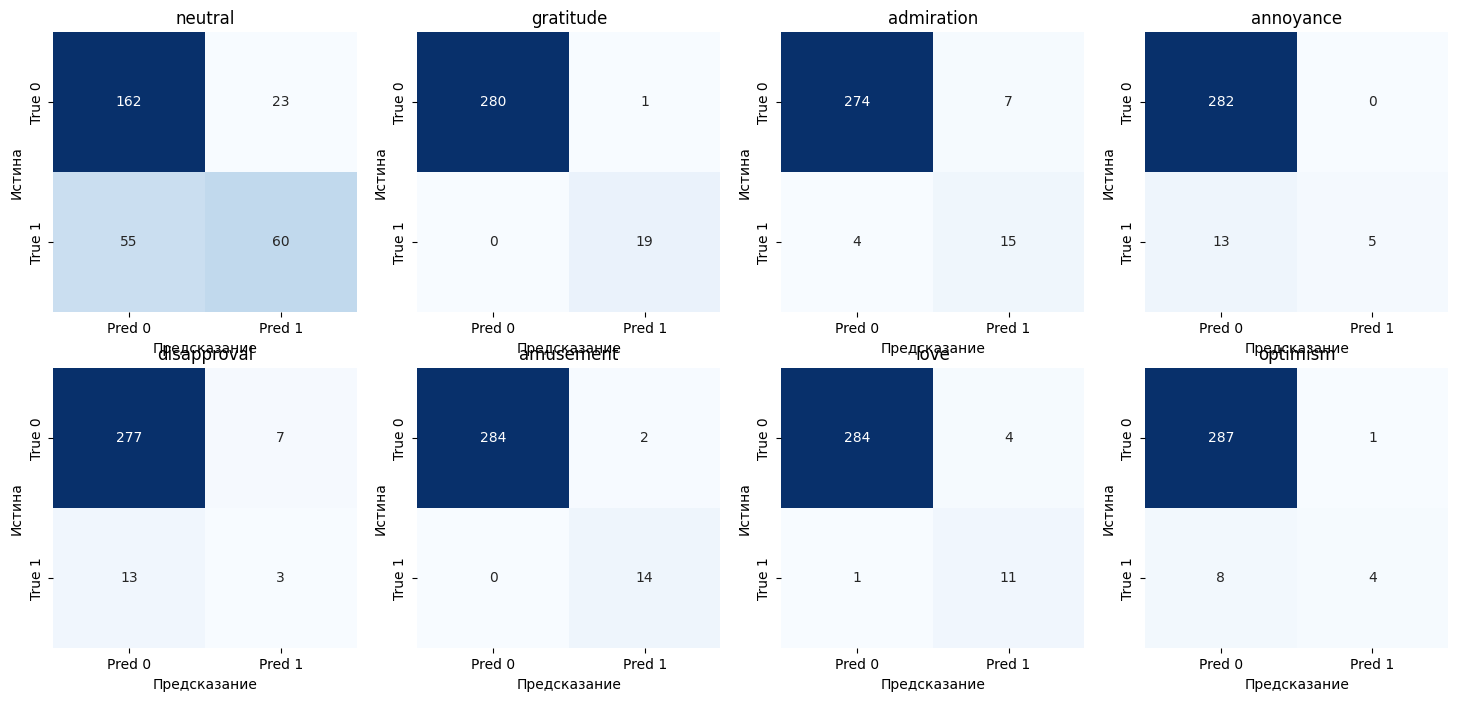

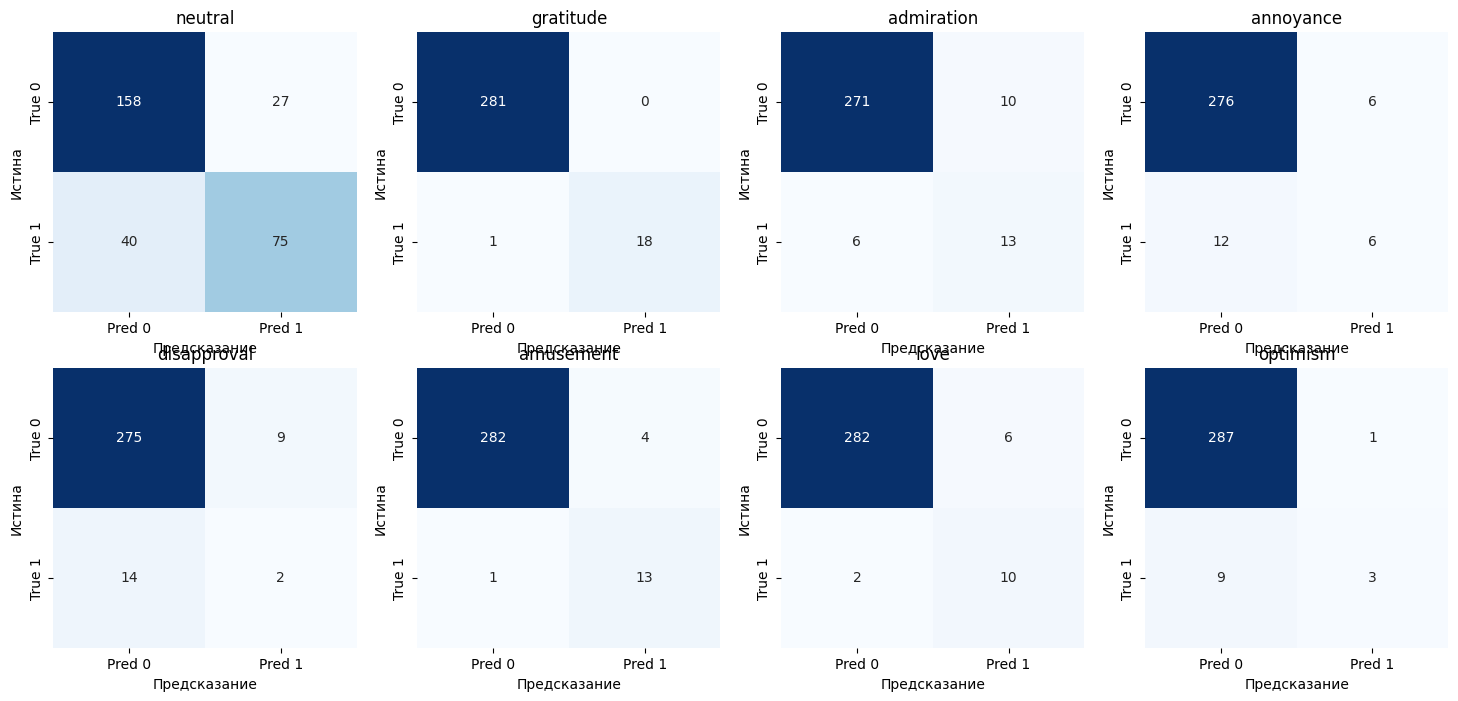

In [58]:
from sklearn.metrics import multilabel_confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def draw_matrix(mcm, top_labels):
    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    axes = axes.flatten()

    for i, (label, matrix) in enumerate(zip(top_labels, mcm)):
        sns.heatmap(
            matrix,
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=False,
            xticklabels=["Pred 0", "Pred 1"],
            yticklabels=["True 0", "True 1"],
            ax=axes[i]
        )
        axes[i].set_title(label)
        axes[i].set_xlabel("Предсказание")
        axes[i].set_ylabel("Истина")

plt.suptitle("Multilabel Confusion Matrix для 8 самых частых эмоций", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

if isinstance(id2label, dict):
    label_names = [id2label[i] for i in range(len(id2label))]
else:
    label_names = list(id2label)

# Выбираем 8 самых частых эмоций по истинной разметке
label_frequencies = y_true.sum(axis=0)
top_k = 8
top_indices = np.argsort(label_frequencies)[-top_k:][::-1]
top_labels = [label_names[i] for i in top_indices]

print("8 самых частых эмоций:")
for idx in top_indices:
    print(f"{label_names[idx]}: {int(label_frequencies[idx])}")

mcm_light = multilabel_confusion_matrix(y_true[:, top_indices], light_preds[:, top_indices])
mcm_heavy = multilabel_confusion_matrix(y_true[:, top_indices], heavy_preds[:, top_indices])
draw_matrix(mcm_light, top_labels)
draw_matrix(mcm_heavy, top_labels)

## Шаг 5: Анализ ошибок — где модель ошибается?

In [59]:
# Найдём примеры, где модели расходятся
disagreements = []
for i in range(len(texts)):
    if not np.array_equal(light_preds[i], heavy_preds[i]):
        disagreements.append({
            'text': texts[i],
            'true': decode_prediction(y_true[i], label_names),
            'light_pred': decode_prediction(light_preds[i], label_names),
            'heavy_pred': decode_prediction(heavy_preds[i], label_names),
            'light_top5': top_k_from_probs(light_probs[i], label_names, k=5),
            'heavy_top5': top_k_from_probs(heavy_probs[i], label_names, k=5),
        })

print(f'Количество примеров, где модели расходятся: {len(disagreements)} из {len(texts)}')

Количество примеров, где модели расходятся: 108 из 300


In [60]:
# Показываем несколько расхождений
for i, item in enumerate(disagreements[:3], 1):
    print(f'--- Расхождение {i} ---')
    print('Текст:', item['text'])
    print('Истинные метки:', item['true'])
    print('Лёгкая модель:', item['light_pred'])
    print('Тяжёлая модель:', item['heavy_pred'])
    print('Top-5 light:', item['light_top5'])
    print('Top-5 heavy:', item['heavy_top5'])
    print()

--- Расхождение 1 ---
Текст: I’m really sorry about your situation :( Although I love the names Sapphira, Cirilla, and Scarlett!
Истинные метки: ['sadness']
Лёгкая модель: ['remorse']
Тяжёлая модель: ['love']
Top-5 light: [('remorse', 0.6126285791397095), ('love', 0.46420830488204956), ('sadness', 0.3903596103191376), ('caring', 0.0646912157535553), ('grief', 0.02938021905720234)]
Top-5 heavy: [('love', 0.5213435292243958), ('remorse', 0.3228814899921417), ('sadness', 0.24334818124771118), ('caring', 0.19468443095684052), ('grief', 0.0961538553237915)]

--- Расхождение 2 ---
Текст: Kings fan here, good luck to you guys! Will be an interesting game to watch! 
Истинные метки: ['excitement']
Лёгкая модель: ['optimism']
Тяжёлая модель: ['excitement']
Top-5 light: [('optimism', 0.8295794725418091), ('gratitude', 0.1833072453737259), ('caring', 0.10974941402673721), ('approval', 0.09026165306568146), ('admiration', 0.07495580613613129)]
Top-5 heavy: [('excitement', 0.5950288772583008), ('adm

In [61]:
# Где каждая модель ошибается сильнее всего?
light_errors = []
heavy_errors = []

for i in range(len(texts)):
    if not np.array_equal(light_preds[i], y_true[i]):
        light_errors.append(i)
    if not np.array_equal(heavy_preds[i], y_true[i]):
        heavy_errors.append(i)

print(f'Ошибок у лёгкой модели: {len(light_errors)}')
print(f'Ошибок у тяжёлой модели: {len(heavy_errors)}')

Ошибок у лёгкой модели: 156
Ошибок у тяжёлой модели: 150


In [63]:
## Шаг 6: Тест на своих текстах

In [64]:
my_texts = [
    'I am so excited and grateful for your help!',
    'This is awful. I am angry and disappointed.',
    'I did not expect that at all, now I am confused and a bit scared.',
    'Thanks, that was very kind of you.',
    'Leave me alone. I am tired of this.'
]

my_light_probs, my_light_preds = batch_predict(my_texts, light_tokenizer, light_model, threshold=THRESHOLD, batch_size=8)
my_heavy_probs, my_heavy_preds = batch_predict(my_texts, heavy_tokenizer, heavy_model, threshold=THRESHOLD, batch_size=8)

for i, text in enumerate(my_texts):
    print('=' * 100)
    print('Текст:', text)
    print('Лёгкая модель:', decode_prediction(my_light_preds[i], label_names))
    print('Top-5 light:', top_k_from_probs(my_light_probs[i], label_names, k=5))
    print('Тяжёлая модель:', decode_prediction(my_heavy_preds[i], label_names))
    print('Top-5 heavy:', top_k_from_probs(my_heavy_probs[i], label_names, k=5))
    print()

Текст: I am so excited and grateful for your help!
Лёгкая модель: ['excitement', 'gratitude']
Top-5 light: [('excitement', 0.6984665393829346), ('gratitude', 0.6499045491218567), ('joy', 0.1304062008857727), ('admiration', 0.06030582636594772), ('surprise', 0.05071112886071205)]
Тяжёлая модель: ['excitement', 'gratitude']
Top-5 heavy: [('excitement', 0.900762140750885), ('gratitude', 0.5913470387458801), ('admiration', 0.08976300060749054), ('joy', 0.05201776698231697), ('approval', 0.029441116377711296)]

Текст: This is awful. I am angry and disappointed.
Лёгкая модель: ['disgust']
Top-5 light: [('disgust', 0.5385082364082336), ('anger', 0.4212952256202698), ('annoyance', 0.26323726773262024), ('disappointment', 0.09546901285648346), ('sadness', 0.03050372377038002)]
Тяжёлая модель: ['anger']
Top-5 heavy: [('anger', 0.7903322577476501), ('disgust', 0.2215116173028946), ('disappointment', 0.1274229884147644), ('annoyance', 0.06221737340092659), ('sadness', 0.02842741832137108)]

Текст: